# Using YOLO (You Only Look Once) for image classification in PyTorch

## Frame the Problem

1. What is the **Business Objective** in Building this Machine Learning Model?
    - **Goal:** To identify phones in images
  
2. How does the company expect to use and benefit from this model?
    - The model is intended to locate phones within images, for example in scenarios such as retrieving lost items or assisting visual search applications.

3. Performance Metrics Used
    - Primarily **IoU**, we are focused on correctly identifying where the phone is in each image.
  
4. Assumptions Made
    1. There is a phone in each image
    2. Labels are correct
    3. Each pixel is an independent observation of the image comprising of a larger 2D picture

## Install YOLO and PyTorch in Env

import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs])

pip_install("torch", "torchvision",
            "--index-url", "https://download.pytorch.org/whl/cpu")
pip_install("matplotlib", "Pillow", "pandas", "numpy", "kaggle", "scikit-learn")

print("All packages installed.")

##  Imports

In [78]:
import os
import random
import shutil
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import ops
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device   : {device}")

PyTorch  : 2.11.0+cpu
CUDA     : False
Device   : cpu


## Get the data

In [52]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "cell phone"
LABELS_DIR = DATA_DIR / "labels"

DATA_DIR.mkdir(exist_ok=True)

os.system(f'kaggle datasets download -d samuelayman/cell-phone -p "{BASE_DIR}" --unzip')
print("Download complete")
print(f"Images : {len(list(DATA_DIR.glob('*.jpg')))}")
print(f"Labels : {len(list(LABELS_DIR.glob('*.txt')))}")

Dataset URL: https://www.kaggle.com/datasets/samuelayman/cell-phone
License(s): apache-2.0


100%|██████████| 129M/129M [00:02<00:00, 51.9MB/s] 



Download complete
Images : 1000
Labels : 1000


In [53]:
# This was entirely generated by Claude as I just needed to cleanup the data due to gaps within it

# ── Step 1: Collect all matching pairs ───────────────────────────────────────
# Find all jpg files in main folder that have a matching label
pairs = []
for fname in os.listdir(DATA_DIR):
    if not fname.endswith(".jpg"):
        continue
    label_path = LABELS_DIR / (Path(fname).stem + ".txt")
    if label_path.exists():
        pairs.append(fname)

# Sort them so renaming happens in order
pairs.sort(key=lambda x: int(x.replace('40_', '').replace('.jpg', '')))

print(f"Found {len(pairs)} matching pairs")
print("First 5:", pairs[:5])
print("Last 5:", pairs[-5:])

# ── Step 2: Rename to temp names first ───────────────────────────────────────
# We rename to temp names first to avoid collisions
# e.g. if 40_8 already exists and we try to rename 40_10 to 40_8 it would clash
for fname in pairs:
    stem = Path(fname).stem
    os.rename(DATA_DIR / fname, DATA_DIR / f"tmp_{fname}")
    os.rename(LABELS_DIR / f"{stem}.txt", LABELS_DIR / f"tmp_{stem}.txt")

# ── Step 3: Rename temp names to clean sequential names ──────────────────────
for new_idx, fname in enumerate(pairs, start=1):
    stem = Path(fname).stem
    os.rename(DATA_DIR / f"tmp_{fname}", DATA_DIR / f"40_{new_idx}.jpg")
    os.rename(LABELS_DIR / f"tmp_{stem}.txt", LABELS_DIR / f"40_{new_idx}.txt")

print("Re-indexing complete")
print(f"Images : {len(list(DATA_DIR.glob('*.jpg')))}")
print(f"Labels : {len(list(LABELS_DIR.glob('*.txt')))}")
print("Done!")

Found 1000 matching pairs
First 5: ['40_1.jpg', '40_2.jpg', '40_3.jpg', '40_5.jpg', '40_7.jpg']
Last 5: ['40_2160.jpg', '40_2165.jpg', '40_2166.jpg', '40_2168.jpg', '40_2175.jpg']
Re-indexing complete
Images : 1000
Labels : 1000
Done!


In [54]:
#inventory all image/label pairs
records = []
for img_path in sorted(DATA_DIR.glob("*.jpg")):
    label_path = LABELS_DIR / (img_path.stem + ".txt")
    if not label_path.exists():
        continue
    records.append({
        "image" : str(img_path),
        "label" : str(label_path),
    })

df = pd.DataFrame(records)
print(f"Total samples : {len(df)}")
print(df.head())

Total samples : 1000
                                               image  \
0  /mnt/c/Users/ryann/1rn/ML/YOLOImageClassificat...   
1  /mnt/c/Users/ryann/1rn/ML/YOLOImageClassificat...   
2  /mnt/c/Users/ryann/1rn/ML/YOLOImageClassificat...   
3  /mnt/c/Users/ryann/1rn/ML/YOLOImageClassificat...   
4  /mnt/c/Users/ryann/1rn/ML/YOLOImageClassificat...   

                                               label  
0  /mnt/c/Users/ryann/1rn/ML/YOLOImageClassificat...  
1  /mnt/c/Users/ryann/1rn/ML/YOLOImageClassificat...  
2  /mnt/c/Users/ryann/1rn/ML/YOLOImageClassificat...  
3  /mnt/c/Users/ryann/1rn/ML/YOLOImageClassificat...  
4  /mnt/c/Users/ryann/1rn/ML/YOLOImageClassificat...  


# EDA

(np.float64(-0.5), np.float64(639.5), np.float64(490.5), np.float64(-0.5))

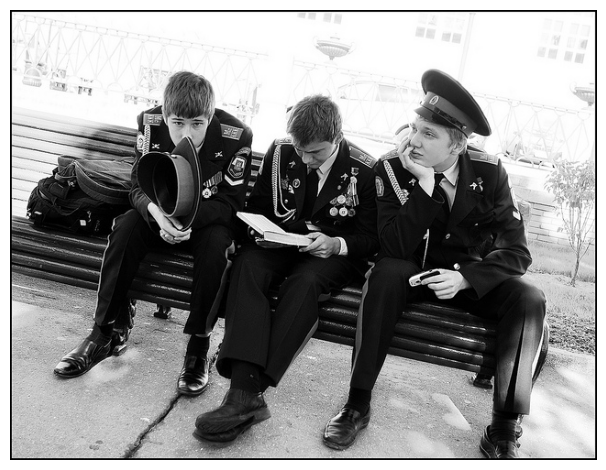

In [56]:
img = Image.open(df["image"][0]).convert("RGB")
plt.imshow(img)
plt.axis("off")

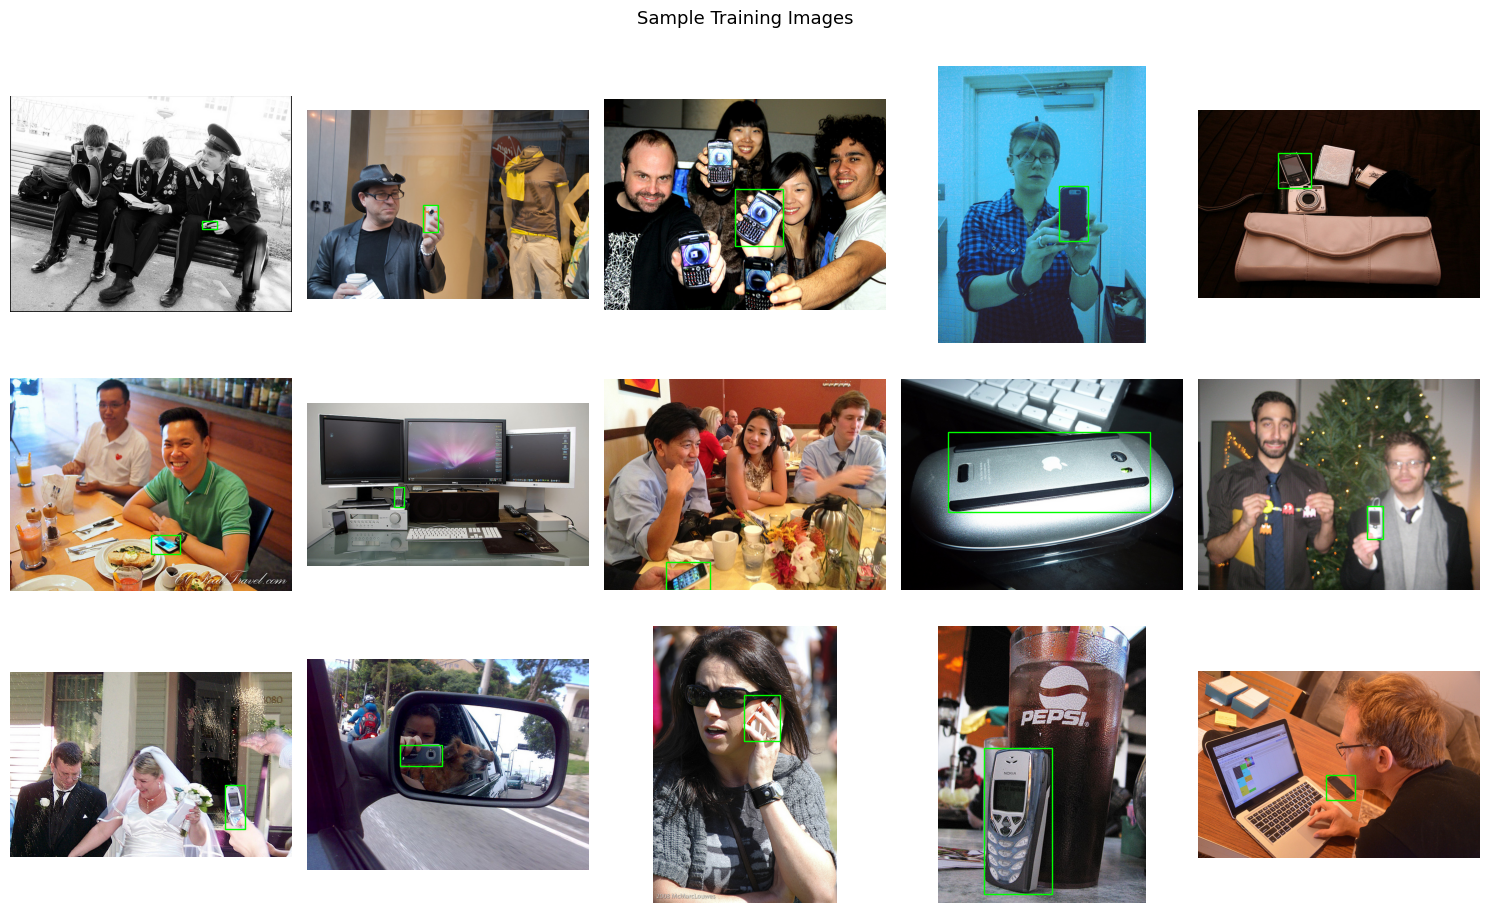

In [57]:
n_rows = 3
n_cols = 5

plt.figure(figsize=(n_cols * 3, n_rows * 3))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        if index >= len(df): break

        ax = plt.subplot(n_rows, n_cols, index + 1)

        img = Image.open(df["image"][index]).convert("RGB")
        W, H = img.size
        ax.imshow(img)
        ax.axis("off")

        #draw rectangle around phone from label
        with open(df["label"][index]) as f:
            parts = f.read().strip().split()
        x_c = float(parts[1]) * W
        y_c = float(parts[2]) * H
        bw = float(parts[3]) * W
        bh = float(parts[4]) * H

        rect = patches.Rectangle(
            (x_c - bw/2, y_c - bh/2), bw, bh,
            linewidth=1, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)

plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.suptitle("Sample Training Images", fontsize=13, y=1.01)
plt.show()

## Prepare the data and model for training

In [58]:
plt.rc('image', cmap='gray')
plt.rc('figure', autolayout=True)

class PhoneYOLODataset(Dataset):
    def __init__(self, image_dir, labels_dir):
        self.image_dir = image_dir
        self.image_paths = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
        self.labels_dir = labels_dir
        self.labels_paths = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]
        # -- Distortion transform, letterbox is better but more complicated --
        self.transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_paths)

    # -- getitem is what PyTorch si calling during dataset iteration --
    def __getitem__(self, idx):
        # -- Load and transform image --
        image = Image.open(os.path.join(self.image_dir, self.image_paths[idx])).convert('RGB')
        image = self.transform(image)

        # -- Load label --
        label_path = os.path.join(self.labels_dir, self.labels_paths[idx])
        with open(label_path, 'r') as f:
            phone_data = f.readlines()[0].strip()
        
        # -- important part: converting from YOLO format (as seen in dataset) to our label tensor --
        data_parts = phone_data.split()
        x_center = float(data_parts[1])
        y_center = float(data_parts[2])
        width = float(data_parts[3])
        height = float(data_parts[4])

        label = torch.zeros(5,8,8)

        grid_x = int(x_center * 8)
        grid_y = int(y_center * 8)

        grid_x = min(grid_x, 7)
        grid_y = min(grid_y, 7)

        label[0, grid_y, grid_x] = x_center
        label[1, grid_y, grid_x] = y_center
        label[2, grid_y, grid_x] = width
        label[3, grid_y, grid_x] = height
        label[4, grid_y, grid_x] = 1.0

        return image, label

print("Done!")

Done!


## Select, train, fine-tune, and save the model

In [59]:
class YoloModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.convo_layer_1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.batch_norm_1 = nn.BatchNorm2d(16)
        self.convo_layer_2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.batch_norm_2 = nn.BatchNorm2d(32)
        self.convo_layer_3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.batch_norm_3 = nn.BatchNorm2d(64)

        #self.dense_layer = nn.Linear(64 * 8 * 8, 1000) 
        #self.output_layer = nn.Linear(1000, 5) 
        self.detection_head = nn.Conv2d(64, 5, kernel_size=1)
    def forward(self, x):
        x = F.leaky_relu(self.batch_norm_1(self.convo_layer_1(x)), negative_slope=0.1)
        x = F.max_pool2d(x, 2)
        x = F.leaky_relu(self.batch_norm_2(self.convo_layer_2(x)), negative_slope=0.1)
        x = F.max_pool2d(x, 2)
        x = F.leaky_relu(self.batch_norm_3(self.convo_layer_3(x)), negative_slope=0.1)
        x = F.max_pool2d(x, 2)
        #x = x.view(x.size(0), -1)
        #x = F.leaky_relu(self.dense_layer(x))
        #x = self.output_layer(x)
        x = self.detection_head(x)
        return x

model = YoloModel().to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

Model parameters: 24,133


In [60]:
def calculate_yolo_loss(predictions, targets, lambda_coord=5, lambda_noobj=0.5):
    # -- Extract predicted bounding boxes and confidence scores and their target counterparts --
    predicted_boxes = predictions[:, 0:4, :, :]
    predicted_confidences = predictions[:, 4:5, :, :]
    target_boxes = targets[:, 0:4, :, :]
    target_confidences = targets[:, 4:5, :, :]

    # -- Custom object classifier --
    obj_mask = target_confidences
    noobj_mask = 1 - obj_mask

    # -- Calculate losses --
    # -- Box loss (for cells with objects) --
    box_loss = torch.sum(
        obj_mask * torch.sum((predicted_boxes - target_boxes) ** 2, dim=1, keepdim=True)
    )
    # -- Confidence loss --
    obj_conf_loss = torch.sum(
        obj_mask * (predicted_confidences - target_confidences) ** 2
    )
    noobj_conf_loss = torch.sum(
        noobj_mask * (predicted_confidences - target_confidences) ** 2
    )

    # -- Total loss --
    # You multiply by lambda_coord to give more wiehgt to box_loss and by lambda_noobj to give less weight to noobj_conf_loss since most cells will likely not have anything in it
    total_loss = (lambda_coord * box_loss) + obj_conf_loss + (lambda_noobj * noobj_conf_loss)

    return total_loss

print("Done!")

Done!


In [86]:
EPOCHS = 300
LR = 0.001

print(f"Training on: {device}")
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
history = {"train_loss": []}

# -- load dataset --
dataset = PhoneYOLODataset(
    image_dir = r'cell phone',
    labels_dir = r'cell phone/labels'
)

# split into train / val / test (80/10/10) sets
n = len(dataset)
n_train = int(n * 0.80)
n_val = int(n * 0.10)
n_test = n - n_train - n_val

train_set, val_set, test_set = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)
# bit weird, PyTorch has class "DataLoader" that handles batching and data shuffling (aka not going straight through dataset)
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False)
test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

print(f"Train : {len(train_set)}")
print(f"Val   : {len(val_set)}")
print(f"Test  : {len(test_set)}")

# -- training loop --
for epoch in range(EPOCHS):
    # model.train() is a PyTorch thing that sets the model to training mode. It doesn't do much for our simple model but for more complex models it can affect things like dropout and batch normalization.
    model.train()

    # running_loss entirely for debugging/logging to just track the accuracy over time
    running_loss = 0.0

    # -- loop through batches of data --
    for batch_idx, (images, labels) in enumerate(train_loader):

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # -- forward pass --
        predictions = model(images)

        # -- calculate loss --
        loss = calculate_yolo_loss(predictions, labels)

        # -- backward pass --
        # the three steps of training: zero_grad, backward, step 
        # clears gradients from the previous batch so they don't accumulate
        optimizer.zero_grad()

        # compute gradients
        loss.backward()

        # updates all weights via the gradients
        optimizer.step()

        # logging cont.
        running_loss += loss.item()

    # print average loss per batch for every 10th epoch
    avg_loss = running_loss / len(train_loader)
    if (epoch+1) % 10 == 0 or (epoch+1) == 1: 
        print(f"Epoch {epoch+1:03d}/{EPOCHS}: Avg Loss = {avg_loss:.4f}")
    history["train_loss"].append(avg_loss)
    scheduler.step()

# save trained model
torch.save(model.state_dict(), 'phone_yolo.pth')
print("Model saved as phone_yolo.pth")

Training on: cpu
Train : 800
Val   : 100
Test  : 100
Epoch 001/300: Avg Loss = 9.1557
Epoch 010/300: Avg Loss = 8.3621
Epoch 020/300: Avg Loss = 7.3500
Epoch 030/300: Avg Loss = 6.8069
Epoch 040/300: Avg Loss = 5.6689
Epoch 050/300: Avg Loss = 5.4411
Epoch 060/300: Avg Loss = 5.3969
Epoch 070/300: Avg Loss = 4.8719
Epoch 080/300: Avg Loss = 4.7726
Epoch 090/300: Avg Loss = 4.7413
Epoch 100/300: Avg Loss = 4.5924
Epoch 110/300: Avg Loss = 4.4333
Epoch 120/300: Avg Loss = 4.5035
Epoch 130/300: Avg Loss = 4.4057
Epoch 140/300: Avg Loss = 4.3113
Epoch 150/300: Avg Loss = 4.3411
Epoch 160/300: Avg Loss = 4.2162
Epoch 170/300: Avg Loss = 4.3926
Epoch 180/300: Avg Loss = 4.1443
Epoch 190/300: Avg Loss = 4.0040
Epoch 200/300: Avg Loss = 4.3178
Epoch 210/300: Avg Loss = 4.0892
Epoch 220/300: Avg Loss = 4.1197
Epoch 230/300: Avg Loss = 4.1162
Epoch 240/300: Avg Loss = 4.1314
Epoch 250/300: Avg Loss = 4.1484
Epoch 260/300: Avg Loss = 4.1952
Epoch 270/300: Avg Loss = 4.2223
Epoch 280/300: Avg Loss

In [87]:
#fine-tuning the model (basically the same as initial model above except starts with saved weights instead of random, less epochs, and lower lr)
FT_EPOCHS = 100
FT_LR = 0.0001

ft_model = YoloModel().to(device)
ft_model.load_state_dict(torch.load("phone_yolo.pth", map_location=device))
print("Loaded saved weights")

print(f"Fine-tuning on: {device}")
ft_optimizer = optim.Adam(ft_model.parameters(), FT_LR)
ft_scheduler = optim.lr_scheduler.StepLR(ft_optimizer, step_size=10, gamma=0.5)
ft_history = {"train_loss": []}

for epoch in range(FT_EPOCHS):
    ft_model.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        predictions = ft_model(images)
        loss = calculate_yolo_loss(predictions, labels)
        ft_optimizer.zero_grad()
        loss.backward()
        ft_optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if (epoch+1) % 10 == 0 or (epoch+1) == 1: 
        print(f"Epoch {epoch+1:03d}/{FT_EPOCHS}: Avg Loss = {avg_loss:.4f}")
    ft_history["train_loss"].append(avg_loss)
    ft_scheduler.step()

torch.save(ft_model.state_dict(), "phone_yolo_ft.pth")
print("Fine-tuned model saved as phone_yolo_ft.pth")

Loaded saved weights
Fine-tuning on: cpu
Epoch 001/300: Avg Loss = 4.2758
Epoch 010/300: Avg Loss = 4.2758
Epoch 020/300: Avg Loss = 4.2278
Epoch 030/300: Avg Loss = 4.0710
Epoch 040/300: Avg Loss = 4.0223
Epoch 050/300: Avg Loss = 4.1497
Epoch 060/300: Avg Loss = 4.1177
Epoch 070/300: Avg Loss = 4.0703
Epoch 080/300: Avg Loss = 4.0433
Epoch 090/300: Avg Loss = 4.1310
Epoch 100/300: Avg Loss = 4.1843
Fine-tuned model saved as phone_yolo_ft.pth


## Evaluate the Finalized Model

In [88]:
def evaluate(model, dataloader, name):
    model.eval()
    #IoU = intersection over union, compares prediction box to true box
    iou_scores = []
    #confidence - how confident model is that it's correct
    conf_scores = []
    total_loss = 0.0

    #dont need to calc gradients bc we don't call backward() in this one
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # for preds: 0,1 = x,y of pred box center; 2,3 = w,h of pred box; 4 = confidence
            preds = model(images)
            loss = calculate_yolo_loss(preds, labels)
            total_loss += loss.item()

            preds = preds.cpu()
            labels = labels.cpu()

            #got some help from Claude here
            for i in range(len(images)):
                pred = preds[i]
                label = labels[i]
                
                conf_map = pred[4]
                #get highest confidence cell and convert into (x,y)
                flat_idx = conf_map.argmax()
                gy = (flat_idx // 8).item()
                gx = (flat_idx % 8).item()

                pred_box = pred[:4, gy, gx]
                conf = pred[4, gy, gx].item()

                #get cell with phone and convert to (x,Y)
                gt_flat = label[4].argmax()
                gt_gy = (gt_flat // 8).item()
                gt_gx = (gt_flat % 8).item()
                
                gt_box = label[:4, gt_gy, gt_gx]

                pred_box = pred_box.unsqueeze(0)
                gt_box = gt_box.unsqueeze(0)

                #calc iou and save scores
                iou = ops.box_iou(gt_box, pred_box, fmt="cxcywh")
                iou_scores.append(iou.item())
                conf_scores.append(conf)

    avg_loss = total_loss / len(dataloader)
    mean_iou = np.mean(iou_scores)
    mean_conf = np.mean(conf_scores)
    iou_over_50 = sum(s > 0.5 for s in iou_scores)

    print(f"\n{name}")
    print(f"  Avg Loss        : {avg_loss:.4f}")
    print(f"  Avg IoU         : {mean_iou:.4f}")
    print(f"  Avg Confidence  : {mean_conf:.4f}")
    print(f"  IoU > 0.5       : {iou_over_50} / {len(iou_scores)}")

    return iou_scores, conf_scores, avg_loss

print("Done!")

Done!


## Model predictions


Validation
  Avg Loss        : 30.1626
  Avg IoU         : 0.1296
  Avg Confidence  : 0.4294
  IoU > 0.5       : 14 / 100

Test
  Avg Loss        : 35.2163
  Avg IoU         : 0.1527
  Avg Confidence  : 0.4616
  IoU > 0.5       : 15 / 100


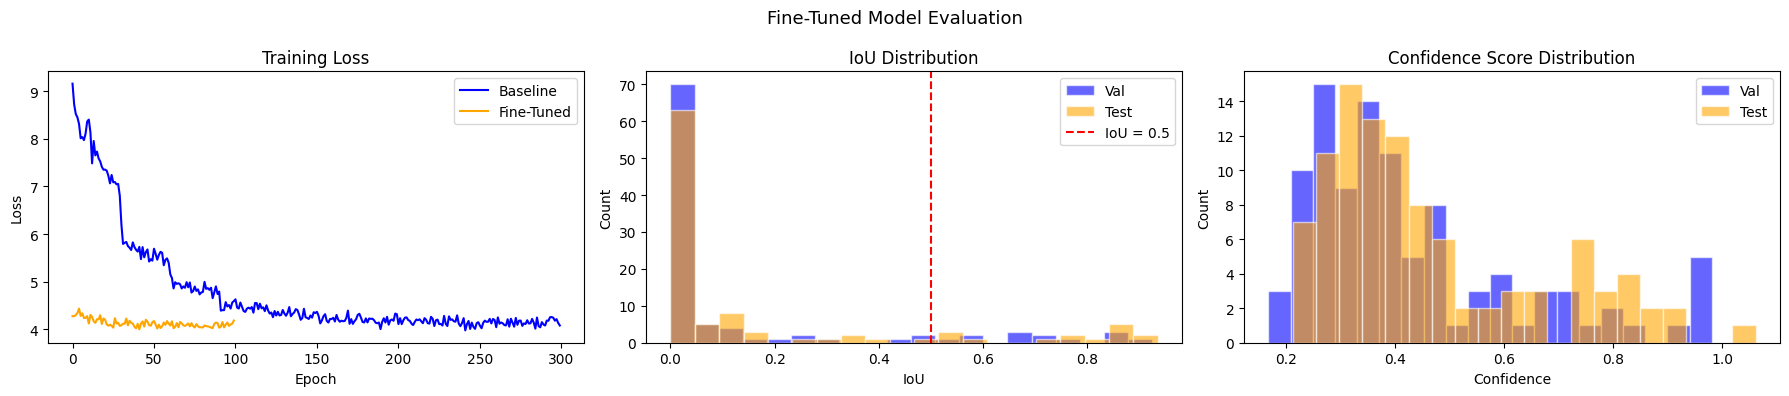

In [90]:
#model predicts
val_ious, val_confs, val_loss = evaluate(ft_model, val_loader, "Validation")
test_ious, test_confs, test_loss = evaluate(ft_model, test_loader, "Test")

#plots
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

#loss curve
axes[0].plot(history["train_loss"], label="Baseline", color="blue")
axes[0].plot(ft_history["train_loss"], label="Fine-Tuned", color="orange")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

#iou dist
axes[1].hist(val_ious, bins=20, alpha=0.6, color="blue", label="Val", edgecolor="white")
axes[1].hist(test_ious, bins=20, alpha=0.6, color="orange", label="Test", edgecolor="white")
axes[1].axvline(0.5, color="red", linestyle="--", label="IoU = 0.5")
axes[1].set_title("IoU Distribution")
axes[1].set_xlabel("IoU")
axes[1].set_ylabel("Count")
axes[1].legend()

#confidence dist
axes[2].hist(val_confs, bins=20, alpha=0.6, color="blue", label="Val", edgecolor="white")
axes[2].hist(test_confs, bins=20, alpha=0.6, color="orange", label="Test", edgecolor="white")
axes[2].set_title("Confidence Score Distribution")
axes[2].set_xlabel("Confidence")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.suptitle("Fine-Tuned Model Evaluation", fontsize=13)
plt.tight_layout()
plt.show()

## anything else?